**Neural networks for road segmentation**
========================

Your next task is to train neural network to segment road on images from car cams.

The original dataset is provided by Karlsruhe Institute of Technology (http://www.cvlibs.net/datasets/kitti/eval_road.php). Their images are ±370x1270, but, for simlictiy, we will use 370x370 squares.

One can download the dataset from https://disk.yandex.ru/d/QPOw4hk84-se_w

Here is an example of input data with corresponding ground truth:

In [3]:
import os
import cv2
import numpy as np

import torchvision.transforms as transforms
from torch.utils.data import Dataset
import albumentations as A
from torch.nn import functional as F

import torch
import torch.nn as nn

from torch import cat as кот

from tqdm import tqdm as тукудум

import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [5]:
def get_paths(path):
    _, _, filenames = next(os.walk(path))

    images_paths = []
    for filename in sorted(filenames):            
        images_paths.append(os.path.join(path, filename))
    
    return np.stack(images_paths)

class RoadDataset(Dataset):
    """Feel free to rewrite it. For ex. cache all images in RAM to increase training speed"""
    def __init__(self, images, masks, transform):
        self.images = sorted(images)
        self.masks = sorted(masks)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):        
        im_name = self.images[idx]
        mask_name = self.masks[idx]

        image = cv2.imread(im_name)[:,:,::-1] / 255.0  # ::-1 to convert from BGR to RGB
        mask = cv2.imread(mask_name, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        sample = {
            'image': image,
            'mask': mask,
        }
        
        img = self.transform(sample['image']).float()
        img = F.pad(img, (22, 22, 22, 22), mode='reflect')
        sample['image'] = img
        sample['mask'] = torch.Tensor([sample['mask']]).float()

        return sample

In [6]:
means, stds = torch.Tensor([0.2644, 0.2753, 0.2784]), torch.Tensor([0.2950, 0.2923, 0.2938])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [7]:
X_train = get_paths("data/train/images")
y_train = get_paths("data/train/gt")

X_test = get_paths("data/test/images")
y_test = get_paths("data/test/gt")

In [8]:
train_dataset = RoadDataset(X_train, y_train, transform)
test_dataset = RoadDataset(X_test, y_test, transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=2,
                                           shuffle=True,
                                           num_workers=16)

test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=2,
                                          shuffle=False,
                                          num_workers=16)

/tmp/ipykernel_2489227/2976372579.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  sample['mask'] = torch.Tensor([sample['mask']]).float()
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8962712..2.4935594].


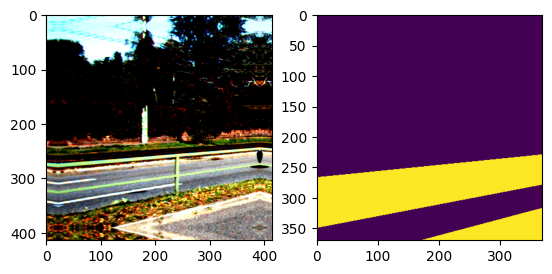

In [9]:
sample = train_dataset[10]
image = sample['image']
mask = sample['mask']

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask.permute(1, 2, 0))

Workflow:
---
* Choose correct loss function, write training loop and code for testing. Feel free to use previous HW for inspiration. 
* Train any segmentation neural network from scratch (for example U-Net) and achieve >= 0.75 IoU on test set (40% points). See function to calculate the metric below.
* Use any pretrained model for image classification, convert it for segmentation by adding decoder (don't forget skip-connections) or usign dilated convolutions and achieve >= 0.87 IoU  on test set (60% points).

You're not allowed to do only one thing: train your network on test set.

----
Your final solution will consist of an ipython notebook with code (for final networks training + any experiments with data) and test metric calculation.

Feel free to ask in Telegram chat if something is not clear :3


In [10]:
print(f"Dataset length {len(train_dataset)}")

Dataset length 648


Dataset is small so actively use data augmentation: rotations, flip, color-change etc. to prevent overfitting.

Most likely you'll have to pad your images to 512x512 (it divides by 2^5=32, like U-Net wants). Use PadIfNeeded from Albumentations and central crop (see below) after prediction to calculate loss/metrics (you don't want to pay attention on padded values).

----
There is a hard data class imbalance in dataset, so the network output will be biased toward "zero" class. You can either tune the minimal probability threshold for the "road" class, or add class weights in optimized loss. You also can try to use softIoU or DICE loss.

Good luck!

In [11]:
def calc_iou(prediction, ground_truth):
    n_images = len(prediction)
    intersection, union = 0, 0
    for i in range(n_images):
        intersection += np.logical_and(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum() 
        union += np.logical_or(prediction[i] > 0, ground_truth[i] > 0).astype(np.float32).sum()
    return float(intersection) / union

In [12]:
def central_crop(images, size):
    current_size = images.size(2)
    border_len = (current_size - size) // 2
    images = images[:, :, border_len:current_size-border_len, border_len:current_size-border_len]
    return images

In [13]:
def calc_metr(model, data_loader):
    model.eval()
    
    total_iou = 0.0
    total_size = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            images = batch['image'].to(device)
            true_masks = batch['mask'].to(device)
            
            outputs = model(images)
            pred_masks = torch.sigmoid(outputs) > 0.5
            
            batch_iou = calc_iou(pred_masks.cpu().numpy(), true_masks.cpu().numpy())
            batch_size = images.size(0)
            total_size += batch_size
            total_iou += batch_iou * batch_size
    
    return total_iou / total_size


In [14]:
class Conv3x3Relu(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels 

        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3)
        self.bn = nn.BatchNorm2d(num_features=out_channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

In [35]:
def train(model, epoch_num=10):
    model.to(device)
    
    criterion = F.binary_cross_entropy_with_logits
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epoch_num):
        model.train()
        total_loss = 0.0
        
        for batch_idx, data in тукудум(enumerate(train_loader)):
            images, masks = data['image'].to(device), data['mask'].to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Test metric: {calc_metr(model, test_loader)}, Train metric: {calc_metr(model, train_loader)}')

In [16]:
class UNet(nn.Module):
    def __init__(self, in_channels = 3, out_channels = 1):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        # 414x414x3

        self.conv2 = Conv3x3Relu(in_channels=self.in_channels, out_channels=64) # 412x412x64
        self.conv3 = Conv3x3Relu(in_channels=64, out_channels=128) # 410x410x128
        self.conv4 = Conv3x3Relu(in_channels=128, out_channels=128) # 408x408x128
        # remember after it

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 204x204x128
        self.conv5 = Conv3x3Relu(in_channels=128, out_channels=256) # 202x202x256
        self.conv6 = Conv3x3Relu(in_channels=256, out_channels=256) # 200x200x256
        # remember after it

        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # 100x100x256
        self.conv7 = Conv3x3Relu(in_channels=256, out_channels=512) # 98x98x512
        self.conv8 = Conv3x3Relu(in_channels=512, out_channels=512) # 96x96x512
        # remember after it

        self.upconv2 = nn.ConvTranspose2d(kernel_size=2, stride=2, in_channels=512, out_channels=256) # 192x192x256
        # should convert to 224x224x256
        self.scaler_up2 = nn.ConvTranspose2d(in_channels=256, out_channels=256, kernel_size=9)
        self.scaler_down2 = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=5, padding_mode='reflect')
        # concat with HxWx256 -> HxWx512 (192x192x512)

        self.conv13 = Conv3x3Relu(in_channels=512, out_channels=256) # 190x190x256
        self.conv14 = Conv3x3Relu(in_channels=256, out_channels=256) # 188x188x256
        self.upconv3 = nn.ConvTranspose2d(kernel_size=2, stride=2, in_channels=256, out_channels=128) # 376x376x128
        # should convert to 456x456x128
        self.scaler_up3 = nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=33)
        self.scaler_down3 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1, padding_mode='reflect')
        # concat with HxWx128 -> HxWx256 (376x376x256)

        self.conv15 = Conv3x3Relu(in_channels=256, out_channels=128) # 374x374x128
        self.conv16 = Conv3x3Relu(in_channels=128, out_channels=64) # 372x372x64
        self.conv17 = Conv3x3Relu(in_channels=64, out_channels=64) # 370x370x64

        self.conv1x1 = nn.Conv2d(in_channels=64, out_channels=self.out_channels, kernel_size=1) # 370x370x2

    def forward(self, x):
        x_128x128 = self.conv4(self.conv3(self.conv2(x)))
        x_256x256 = self.conv6(self.conv5(self.pool2(x_128x128)))
        x = self.conv8(self.conv7(self.pool3(x_256x256)))

        x = self.upconv2(x)
  
        x = self.scaler_up2(x)
        x = кот([x, x_256x256], dim = 1)
        x = self.scaler_down2(x)

        x = self.upconv3(self.conv14(self.conv13(x)))
        x = кот([x, x_128x128], dim = 1)
        x = self.scaler_down3(x)
        x = self.conv17(self.conv16(self.conv15(x)))
        x = self.conv1x1(x)
        x = central_crop(x, 370)
        return x


In [17]:
model = UNet().to(device)
model.load_state_dict(torch.load("./model_066", weights_only=True))
model.eval()

UNet(
  (conv2): Conv3x3Relu(
    (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv3): Conv3x3Relu(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv4): Conv3x3Relu(
    (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv3x3Relu(
    (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv6): Conv3x3Relu(
    (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
    (bn): BatchNo

In [36]:
train(model)

324it [02:16,  2.37it/s]


Epoch 1, Loss: 0.1005, Test metric: 0.6546247005462646, Train metric: 0.7727991938591003


324it [02:17,  2.36it/s]


Epoch 2, Loss: 0.0946, Test metric: 0.6944721341133118, Train metric: 0.8113755583763123


324it [02:17,  2.36it/s]


...

Epoch 7, Loss: 0.0814, Test metric: 0.6730694770812988, Train metric: 0.8088094592094421


324it [03:27,  1.56it/s]


Epoch 8, Loss: 0.0821, Test metric: 0.6989072561264038, Train metric: 0.8098798990249634


8it [00:06,  1.28it/s]


KeyboardInterrupt: 

In [19]:
# torch.save(model.state_dict(), "./model_066")

In [20]:
model(sample['image'].unsqueeze(0).to(device)).to('cpu').squeeze(1)

tensor([[[-6.2062, -6.5357, -6.7341,  ..., -7.8720, -7.7956, -7.6448],
         [-6.9388, -7.1578, -7.2913,  ..., -8.2187, -8.1819, -8.0873],
         [-7.0245, -7.1924, -7.3203,  ..., -8.2962, -8.2596, -8.1898],
         ...,
         [-4.4588, -4.5595, -4.3229,  ...,  2.2654,  2.0750,  1.9527],
         [-4.5479, -4.7121, -4.4115,  ...,  1.9670,  1.8646,  1.7567],
         [-4.5429, -4.7072, -4.4390,  ...,  1.7365,  1.6521,  1.6161]]],
       grad_fn=<SqueezeBackward1>)

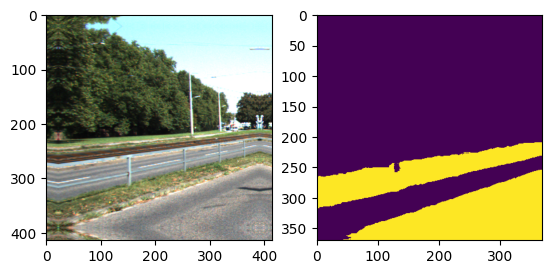

In [32]:
# sample = train_dataset[193]
# image = sample['image']
# mask = model(sample['image'].unsqueeze(0).to(device)).to('cpu')
# # mask = sample['mask']

# plt.subplot(1, 2, 1)
# plt.imshow(image.permute(1, 2, 0))
# plt.subplot(1, 2, 2)
# plt.imshow(torch.sigmoid(mask.squeeze(1).permute(1, 2, 0)).detach().numpy())
# # plt.imshow(mask.permute(1, 2, 0))

sample = train_dataset[15]
image = transforms.Normalize(mean=-1*means/stds, std=1/stds)(sample['image'])
mask = sample['mask']
pred = model.forward(torch.unsqueeze(sample['image'].to('cuda'), dim=0))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow((torch.sigmoid(pred[0]) > 0.5).permute(1, 2, 0).cpu().detach().numpy())


### PART 2

In [ ]:
import torchvision.models as models

In [ ]:
resnet18 = models.resnet18(pretrained=True).to(device)
resnet18.named_parameters

In [ ]:
class Conv3x3Safe(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels 

        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(num_features=out_channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

In [ ]:
class ResNet18Mutant(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.resnet_part = nn.Sequential(
            resnet18.conv1,
            resnet18.bn1,
            resnet18.relu,
        )

        self.pool = resnet18.maxpool

        self.block_1 = resnet18.layer1
        self.block_2 = resnet18.layer2
        self.block_3 = resnet18.layer3
        self.block_4 = resnet18.layer4
        
        self.upconv1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = Conv3x3Safe(512, 256)
        self.conv2 = Conv3x3Safe(256, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2, padding=1)
        self.conv3 = Conv3x3Safe(256, 128)
        self.conv4 = Conv3x3Safe(128, 128)
        
        self.upconv3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv5 = Conv3x3Safe(128, 64)
        self.conv6 = Conv3x3Safe(64, 64)
        
        self.upconv4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.conv7 = Conv3x3Safe(128, 64)
        self.flatten = nn.ConvTranspose2d(in_channels=64, out_channels=1, kernel_size=2)
        
    def forward(self, x):
        y = self.resnet_part(x)
        
        e1 = self.block_1(y)
        e2 = self.block_2(e1)
        e3 = self.block_3(e2)
        e4 = self.block_4(e3)
        
        x = self.upconv1(e4)
        x = torch.cat([e3, x], dim=1)
        x = self.block_1(x)
        
        x = self.upconv2(x)
        x = self.upconv3(x)
        x = torch.cat([nn.AvgPool2d(kernel_size=2, stride=1)(e1), x], dim=1)
        x = self.block_3(x)
        x = self.upconv4(x)
        x = torch.cat([nn.AvgPool2d(kernel_size=2, stride=1)(x0), x], dim=1)
        x = self.decoder4(x)
        #x = self.dropout(x)
        x = nn.AvgPool2d(kernel_size=2, stride=1, padding=1)(self.upconv5(x))
        #x = self.final_conv(x)
        x = self.last(x)
        
        return x
